# QAOA — Max Cut Problem 


**Graph (Square):**
```
0 ——— 1
|     |
3 ——— 2
```
**Goal:** Split nodes into 2 groups so the maximum number of edges cross between groups.


Readme:

The code below needs a python environment with the following libraries and modules installed:

qiskit (ver:2.1.0),
scipy,
matplotlib.pyplot,
matplotlib.patches,
numpy,
qiskit_aer,

In [14]:
# ── Imports ───────────────────────────────────────────

import numpy as np                      # math and array operations
import matplotlib.pyplot as plt         # plotting
from matplotlib.patches import Patch    # for legend colored boxes
from scipy.optimize import minimize     # classical optimizer
from qiskit import QuantumCircuit       # build quantum circuits
from qiskit_aer import AerSimulator    # local quantum simulator

In [15]:
# ── Problem Setup ─────────────────────

n     = 4                               # number of nodes = number of qubits
edges = [(0,1), (1,2), (2,3), (3,0)]   # 4 edges of the square graph
#edges = [(0,1), (1,2), (2,3), (3,0), (0,2), (1,3)]   # 6 edges of the square graph 

p     = 3                               # For circuit Depth

SHOTS = 1024                            # shots per circuit evaluation during optimization
sim   = AerSimulator()                  # the quantum simulator

print(f"Graph edges  : {edges}")
print(f"Qubits       : {n}")
print(f"QAOA depth   : p = {p}")
print(f"Parameters   : {2*p}  ({p} gammas + {p} betas)")  
                                        # each layer adds 1 gamma and 1 beta
                                        # so total parameters = 2*p

Graph edges  : [(0, 1), (1, 2), (2, 3), (3, 0)]
Qubits       : 4
QAOA depth   : p = 3
Parameters   : 6  (3 gammas + 3 betas)


In [16]:
# ── Build the QAOA Circuit (works for ANY p) ──────────
# The first p values are gammas, the last p values are betas

def qaoa_circuit(params):              

    gammas = params[:p]                 # first p elements  → cost unitary angles
    betas  = params[p:]                 # last  p elements  → mixer unitary angles

    qc = QuantumCircuit(n)              # create circuit with n qubits

    # ── Step A: Initial State ─────────────────────────────────
    qc.h(range(n))                      # Hadamard on all qubits → equal superposition
                                        # all 2^n bitstrings exist simultaneously

    # ── Step B: Repeat p layers of Cost + Mixer ───────────────
    for layer in range(p):             # iterate over each QAOA layer 0, 1, ..., p-1

        g = gammas[layer]               # gamma for this layer
        b = betas[layer]                # beta  for this layer

        for (i, j) in edges:           # for each edge in the graph

            qc.cx(i, j)                 # CNOT: checks if qubits i and j differ
            qc.rz(2 * g, j)            # Rz: applies phase based on whether edge is cut
            qc.cx(i, j)                 # CNOT: uncomputes the entanglement

        for q in range(n):             # for every qubit
            qc.rx(2 * b, q)            # Rx rotation: lets nodes consider switching groups

    qc.measure_all()                    # measure all qubits at the end
    return qc                           # return the fully built circuit



In [17]:
# ── Cut Value Calculator ─────────────────────────────
# Counts how many edges are cut for a given measurement bitstring

def count_cut(bitstring):               # input: bitstring like '0101'

    bits = [int(b) for b in reversed(bitstring)]
                                        # Qiskit returns little-endian strings
                                        # rightmost character = qubit 0
                                        # reversing fixes the index alignment

    return sum(                         # count all edges where endpoints are in
        1 for (i, j) in edges           # different groups (bits differ)
        if bits[i] != bits[j]           # bits[i]=0 means node i in group 0, etc.
    )


In [18]:
# ── Objective Function ───────────────────────────────
# Returns the NEGATIVE expected cut value
# Negative because scipy.minimize minimizes, but we want to MAXIMIZE cut

def objective(params):                  # params has length 2*p

    qc     = qaoa_circuit(params)       # build circuit with current parameters
    counts = sim.run(qc, shots=SHOTS).result().get_counts()
                                        # run circuit and get {bitstring: count} dict

    total  = sum(counts.values())       # total number of shots

    exp_cut = sum(                      # weighted average cut value
        count * count_cut(bs)           # multiply count by cut value of that bitstring
        for bs, count in counts.items()
    ) / total                           # divide by total → gives expected value E[cut]

    return -exp_cut                     # negate so minimizer maximizes cut

print("Objective function ready for p =", p)
print("Parameter vector length        :", 2*p)

Objective function ready for p = 3
Parameter vector length        : 6


In [19]:
# ── Run the Classical Optimizer ──────────────────────
# COBYLA adjusts all 2*p parameters to maximize the expected cut

np.random.seed(42)                      # reproducibility

init_params = np.random.uniform(0, np.pi, 2 * p)
                                        # 2*p random starting angles in [0, pi]
                                        # layout: [g1, g2,...,gp, b1, b2,...,bp]

print(f"Optimizing {2*p} parameters for p={p} ...")
print(f"Initial gammas : {init_params[:p].round(3)}")
print(f"Initial betas  : {init_params[p:].round(3)}")

result = minimize(
    objective,                          # function to minimize
    init_params,                        # starting parameter values
    method='COBYLA',                    # gradient-free optimizer
                                        # good choice because quantum circuits are noisy
                                        # and gradients are expensive to compute
    options={
        'maxiter': 150 * p,             # allow more iterations for larger p
                                        # more parameters → needs more iterations to converge
        'rhobeg' : 0.5                  # initial step size for parameter search
    }
)

best_params = result.x                  # optimal parameter array [g1,...,gp, b1,...,bp]
best_cut    = -result.fun               # best expected cut value (undo the negation)

print(f"\n── Optimization Complete ──")
print(f"Best gammas  : {best_params[:p].round(4)}")  # one gamma per layer
print(f"Best betas   : {best_params[p:].round(4)}")  # one beta  per layer
print(f"Best E[cut]  : {best_cut:.4f}  (max possible = 4)")
print(f"Approx ratio : {best_cut/4:.4f}  (1.0 = perfect)")
                                        # approximation ratio = achieved / optimal
                                        # closer to 1.0 = better QAOA performance

Optimizing 6 parameters for p=3 ...
Initial gammas : [1.177 2.987 2.3  ]
Initial betas  : [1.881 0.49  0.49 ]

── Optimization Complete ──
Best gammas  : [1.1336 2.886  2.7654]
Best betas   : [1.8745 0.3173 0.45  ]
Best E[cut]  : 3.8965  (max possible = 4)
Approx ratio : 0.9741  (1.0 = perfect)


In [20]:
# ── Sample the Optimized Circuit ─────────────────────

opt_qc  = qaoa_circuit(best_params)    # build circuit with the BEST parameters found
counts  = sim.run(opt_qc, shots=8192).result().get_counts()
                                        # run 8192 shots for smooth probability distribution

sorted_counts = sorted(counts.items(), key=lambda x: -x[1])
                                        # sort by count descending (most frequent first)

print(f"Top 16 outcomes after optimization (p={p}, 8192 shots):\n")
print(f"  {'Bitstring':>10}  {'Count':>6}  {'Cut':>4}  {'Prob':>8}")
print("  " + "-" * 36)

for bs, cnt in sorted_counts[:16]:      # print only the top 16 most frequent results
    prob = cnt / 8192                   # convert count to probability
    cut  = count_cut(bs)                # compute cut value for this bitstring
    flag = " ← OPTIMAL" if cut > 3 else ""  # mark the optimal ones
    print(f"  {bs:>10}  {cnt:>6}  {cut:>4}  {prob:>7.3f}{flag}")

Top 16 outcomes after optimization (p=3, 8192 shots):

   Bitstring   Count   Cut      Prob
  ------------------------------------
        0101    3839     4    0.469 ← OPTIMAL
        1010    3834     4    0.468 ← OPTIMAL
        0011      94     2    0.011
        1100      91     2    0.011
        1001      90     2    0.011
        0110      84     2    0.010
        0100      26     2    0.003
        1000      23     2    0.003
        1011      21     2    0.003
        0010      20     2    0.002
        1101      19     2    0.002
        1110      19     2    0.002
        0111      16     2    0.002
        0001      14     2    0.002
        0000       1     0    0.000
        1111       1     0    0.000


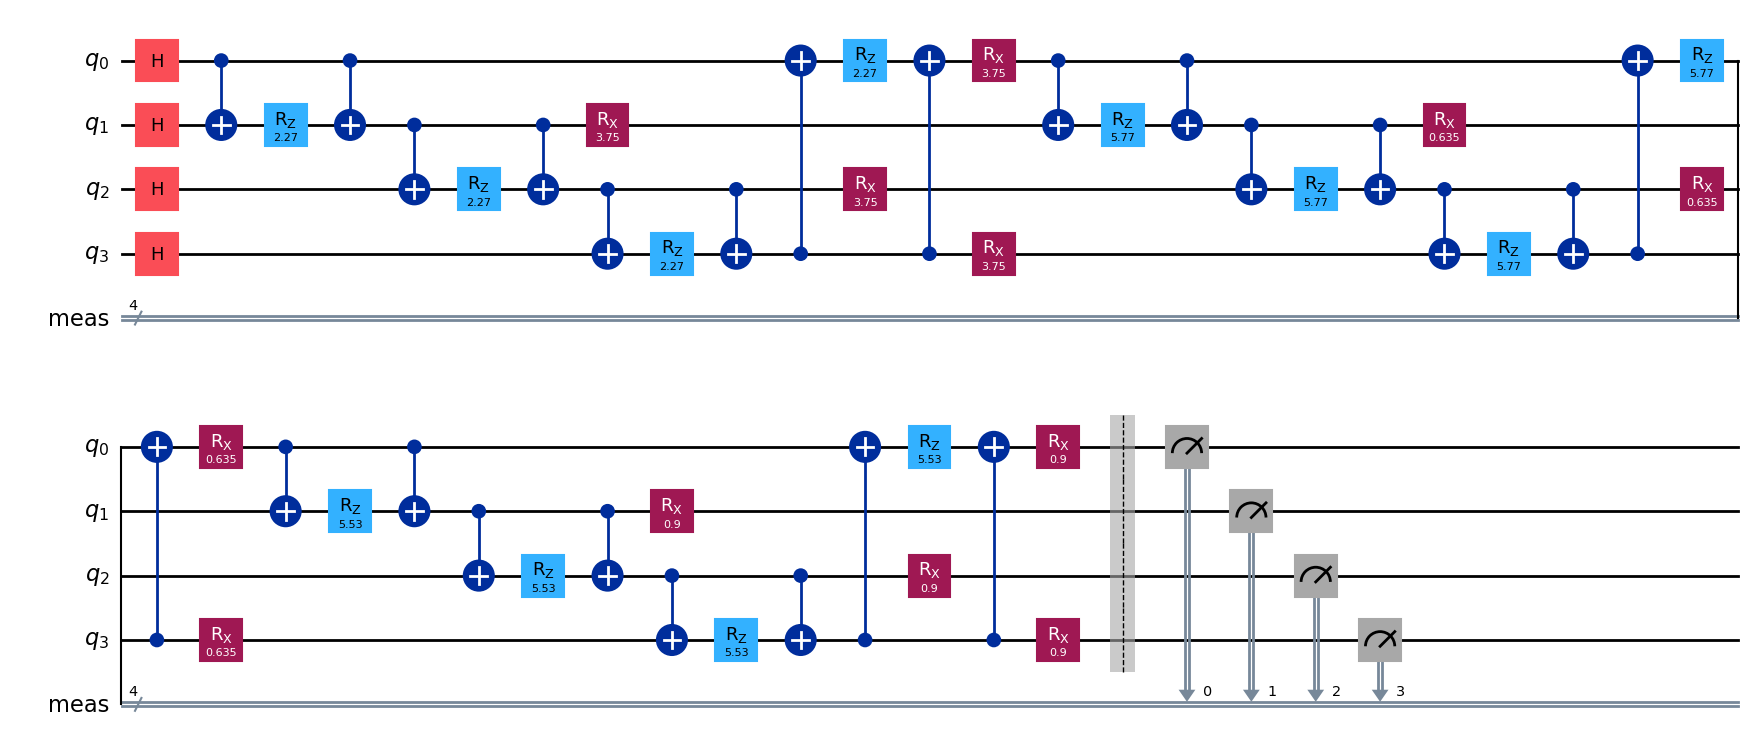

In [21]:
opt_qc.draw('mpl') # draw the optimized circuit diagram

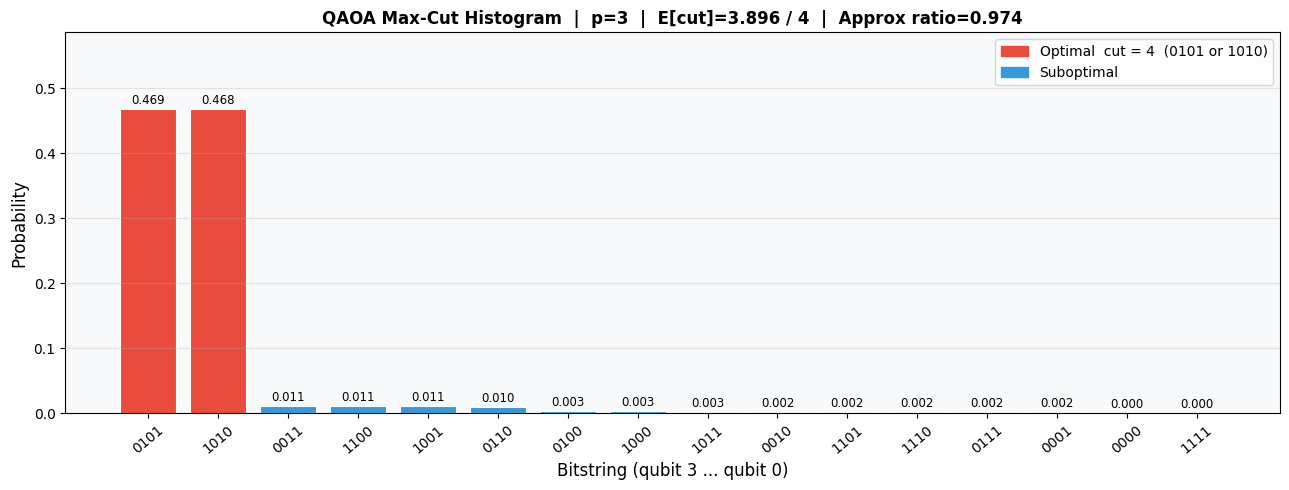

In [22]:
# ── Plot the Histogram ────────────────────────────────

top  = sorted_counts[:16]             # top 16 most frequent bitstrings
labels = [bs for bs, _ in top]       # x-axis: bitstring labels
probs  = [cnt/8192 for _, cnt in top]# y-axis: probabilities

# Color: red = optimal (cut=4), blue = suboptimal
colors = ['#e74c3c' if count_cut(bs) == 4 else '#3498db' for bs in labels]

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(labels, probs, color=colors, edgecolor='white', linewidth=0.8)
                                        # one bar per bitstring

for bar, prob in zip(bars, probs):     # add probability text above each bar
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f'{prob:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('Bitstring (qubit 3 ... qubit 0)', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title(
    f'QAOA Max-Cut Histogram  |  p={p}  |  E[cut]={best_cut:.3f} / 4'
    f'  |  Approx ratio={best_cut/4:.3f}',
    fontsize=12, fontweight='bold'
)                                       # title shows p, achieved cut, and quality ratio
ax.set_ylim(0, max(probs) * 1.25)
ax.tick_params(axis='x', rotation=40)
ax.set_facecolor('#f8f9fa')
ax.grid(axis='y', alpha=0.3)

ax.legend(handles=[
    Patch(color='#e74c3c', label='Optimal  cut = 4  (0101 or 1010)'),
    Patch(color='#3498db', label='Suboptimal')
], fontsize=10)

plt.tight_layout()
plt.show()

# ── What to expect as p increases ─────────────────────────────
# p=1: Red bars exist but share probability with blue bars
# p=2: Red bars become noticeably taller
# p=3: Red bars dominate — QAOA converging to correct answer
# p→∞: Nearly all probability concentrates on 0101 and 1010